# Semantic Link Labs: The Data Detective's Toolkit

> *"I could be wrong. But I'm not."* — Adrian Monk

---

This notebook walks through six **Case Files** using the **SF Case Files** semantic model,
built on real SFPD incident report data from San Francisco.

| Case File | Theme | SLL Capability |
|---|---|---|
| #1 | The Unidentified Model | `list_tables`, `list_columns`, `list_measures` |
| #2 | The Relationship Web | `list_relationships`, `find_relationships` |
| #3 | Running the Numbers | `read_table`, `evaluate_dax` |
| #4 | Something Doesn't Add Up | Referential integrity — `EXCEPT` + `INFO.STORAGETABLES()` |
| #5 | The Evidence Isn't Ready Yet | SQL Analytics Endpoint lag + `refresh_sql_endpoint_metadata()` |
| #6 | The Witness Vanished | `recover_lakehouse_object()` |

**Dataset:** SF Case Files star schema — `fact_Incidents`, `dim_Date`, `dim_CrimeType`, `dim_District`, `dim_Neighborhood`, `dim_Resolution`

**Setting:** San Francisco, CA — Monk's city.

---
## Case File #0 — Stocking the Evidence Room

Before Monk investigates anything, he needs his kit. Gloves, notepad, and in our case — 
Semantic Link Labs.

Every notebook in this session starts with a single `%run` call pointing to a setup 
notebook. That setup notebook lives separately from the demo and handles two things:

- Installing Semantic Link Labs
- Defining all workspace and dataset variables in one place

This pattern matters beyond demo day. In production notebooks, a shared setup notebook 
means one place to update a workspace name, one place to manage your imports, and 
recovery from a dropped session is a single cell — not a scroll back to the top.

> **Two versions live in this workspace:**
> - `00_Setup_Fresh` — installs SLL, then loads imports and variables. Use after a cold session.
> - `00_Setup` — imports and variables only. Use when the session is already warm.

Open `00_Setup_Fresh` now and take a look — the pattern is simple on purpose.

In [1]:
%run 00_Setup_Fresh

StatementMeta(, ed3d21a1-746a-4a16-8c45-f78967d1c339, 4, Finished, Available, Finished, True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fsspec-wrapper 0.1.15 requires PyJWT>=2.6.0, but you have pyjwt 2.4.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
✅ semantic-link-labs 0.14.0 installed
✅ Workspace    : FabConSQLCon2026
✅ Workspace ID : 21df5422-28b3-46aa-a1c5-ae2cd2a48578
✅ Lakehouse    : EvidenceLocker
✅ Lakehouse ID : a5f11fba-90dd-4722-81a9-d9cc0ebc6fdc
✅ Setup complete — the investigation begins


---
## 📁 Case File #1 — "The Unidentified Model"

> *Monk arrives at the scene and catalogs every detail before touching anything.*

Before you analyze data, you understand the **model**.
SLL gives you a forensic inventory of everything inside a semantic model — tables, columns,
data types, hidden fields <br> **— without ever opening Power BI Desktop.**


**Monk never assumes. Neither should you**

In [2]:
# What tables are in this model?
df_tables = fabric.list_tables(DATASET, workspace=WORKSPACE)

print(f"Tables found: {len(df_tables)}")
display(df_tables)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 5, Finished, Available, Finished, False)

Tables found: 6


SynapseWidget(Synapse.DataFrame, fc569efd-1bd1-4e0e-ae43-406fac9ff473)

### Just the Facts (Tables), Ma'am

Monk isn't the only detective worth quoting.

Sergeant Friday didn't care about dimension tables, hidden hierarchies, or 
auto-generated date scaffolding. He wanted facts. Just the facts.

Let's filter down to exactly that.

In [3]:
# Just the facts, ma'am
df_facts = df_tables[df_tables["Name"].str.contains("Fact", case=False, na=False)]

print(f"Fact tables found: {len(df_facts)}")
display(df_facts)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 6, Finished, Available, Finished, False)

Fact tables found: 1


SynapseWidget(Synapse.DataFrame, f0ee30a8-ac1b-431f-91da-30518c0d7707)

### Every Column

In [4]:
# Every column — name, type, hidden status, description
df_columns = fabric.list_columns(DATASET, workspace=WORKSPACE)

print(f"Columns found: {len(df_columns)}")
display(df_columns)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 7, Finished, Available, Finished, False)

Columns found: 40


SynapseWidget(Synapse.DataFrame, 6634466c-ab71-4c5c-b21e-f9ff989e0cbe)

### Calculated Columns — What's DAX vs. What's From the Source?
`df_columns["Type"]` tells you how each column was created:
- `"Data"` — sourced directly from the underlying data (import, DirectQuery, Direct Lake)
- `"Calculated"` — DAX expression evaluated at model refresh time, stored in Vertipaq
This is the fastest way to see where DAX logic is embedded in the model structure
— before you ever open the model in Desktop.

### Calculated Columns - Case 1

In [5]:
# Which columns are calculated (DAX) vs. sourced from the data?
df_columns = fabric.list_columns(DATASET, workspace=WORKSPACE)

df_calculated = df_columns[df_columns["Type"] == "Calculated"]
calculated_count = len(df_calculated)

print(f"Calculated columns: {calculated_count} of {len(df_columns)} total")

if calculated_count > 50:
    print("🚨 RUN AWAY")
elif calculated_count > 25:
    print("😬 WALK AWAY")
else:
    print("🙂 It's a jungle out there")

if not df_calculated.empty:
    display(df_calculated[["Table Name", "Column Name", "Data Type", "Type"]])
else:
    print("No calculated columns found in this model. KratosBI 🏛️ would approve of this.")

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 8, Finished, Available, Finished, False)

Calculated columns: 2 of 40 total
🙂 It's a jungle out there


SynapseWidget(Synapse.DataFrame, 14bc6430-9393-4573-b6a7-6ac9028f80e8)

### Calculated Columns - Case 2

In [6]:
# Which columns are calculated (DAX) vs. sourced from the data?
DATASET_NOCC = "Trudoso10K"
df_columns = fabric.list_columns(DATASET_NOCC, workspace=WORKSPACE)

df_calculated = df_columns[df_columns["Type"] == "Calculated"]
calculated_count = len(df_calculated)

print(f"Calculated columns: {calculated_count} of {len(df_columns)} total")

if calculated_count > 50:
    print("🚨 RUN AWAY")
elif calculated_count > 25:
    print("😬 WALK AWAY")
else:
    print("🙂 It's a jungle out there")

if not df_calculated.empty:
    display(df_calculated[["Table Name", "Column Name", "Data Type", "Type"]])
else:
    print("No calculated columns found in this model. KratosBI 🏛️ would approve of this.")

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 9, Finished, Available, Finished, False)

Calculated columns: 0 of 68 total
🙂 It's a jungle out there
No calculated columns found in this model. KratosBI 🏛️ would approve of this.


### Measures

In [7]:
# Any measures already defined in the model?
df_measures = fabric.list_measures(DATASET, workspace=WORKSPACE)

print(f"Measures found: {len(df_measures)}")
display(df_measures)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 10, Finished, Available, Finished, False)

Measures found: 32


SynapseWidget(Synapse.DataFrame, b9d336b9-1a12-4182-95a1-ce14bce4fb6a)

### Measure Dependencies

Trace the evidence
A single measure can reference a chain of other calculations. This code reveals the dependency trail so you can see how the logic connects.

In [8]:
import sempy.fabric as fabric
import sempy_labs as labs

# All calculation dependencies in the semantic model
deps = fabric.get_model_calc_dependencies(
    dataset=DATASET
)

# Measure-focused dependency view
measure_deps = labs.get_measure_dependencies(
    dataset=DATASET
)

# Tree for one measure
labs.measure_dependency_tree(
    dataset=DATASET,
    measure_name="Case Chaos Index"
)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 11, Finished, Available, Finished, False)

'Case Chaos Index'
├── 'Total Incidents'
│   └── ⊞ 'fact_Incidents'
└── 'Downstream Panic Index'
    ├── 'Incident Complexity Score'
    │   ├── 'Total Incidents'
    │   │   └── ⊞ 'fact_Incidents'
    │   ├── 'Severity Weighted Incidents'
    │   │   ├── ⊞ 'fact_Incidents'
    │   │   └── 'SeverityScore'
    │   ├── 'Active Neighborhoods'
    │   └── 'Active Crime Types'
    ├── 'Investigation Noise Factor'
    │   ├── 'Incident Complexity Score'
    │   │   ├── 'Total Incidents'
    │   │   ├── 'Severity Weighted Incidents'
    │   │   │   ├── ⊞ 'fact_Incidents'
    │   │   │   └── 'SeverityScore'
    │   │   ├── 'Active Neighborhoods'
    │   │   └── 'Active Crime Types'
    │   ├── 'Case Friction Score'
    │   │   ├── 'Avg Response Time (min)'
    │   │   ├── 'Avg Officers Per Incident'
    │   │   ├── 'Online Report Rate'
    │   │   ├── 'Avg Response Time (min)'
    │   │   │   ├── ⊞ 'fact_Incidents'
    │   │   │   ├── 'CallToArrivalMinutes'
    │   │   │   ├── ⊞ 'fact_Incident

---
## 📁 Case File #2 — "The Relationship Web"

> *He sees the connections others miss.*

Two questions:
1. What does Power BI **know** is connected? → `list_relationships`
2. What does the **data** suggest should be connected? → `find_relationships`

**Watch for:** `dim_Neighborhood.DistrictKey` and `dim_District.DistrictKey` —
same values, both tables carry district info, but the relationship between
Neighborhood and District may not be explicitly modeled.
SLL will find it. Power BI didn't.

*"You missed one."*

### Pulling the Case Files — Relationships as Data

Before we can map the web, we need the witness list.

`list_relationships()` returns every modeled relationship in the semantic model as a 
DataFrame — from table, to table, cardinality, cross-filter direction, and whether it's 
active. No clicking through the Model view in Power BI Desktop. It's all here, 
programmatically, in one call.

This is the raw evidence. Every connection the model knows about.

In [9]:
# What relationships does the model currently have?
df_relationships = fabric.list_relationships(DATASET, workspace=WORKSPACE)

print(f"Modeled relationships: {len(df_relationships)}")
display(df_relationships)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 12, Finished, Available, Finished, False)

Modeled relationships: 4


SynapseWidget(Synapse.DataFrame, bc70bc5c-f3b9-4db4-8a71-445b9f5fdaf1)

### The Relationship Web — Visualized

A list of relationships tells you the facts. A graph shows you the shape of the case.

`plot_relationship_metadata()` takes that same DataFrame and renders it as a network 
diagram — tables as nodes, relationships as edges. This is where hidden tables and 
lookup chains that look fine in a list suddenly reveal themselves as something worth 
a second look.

> *"I notice things. It's a blessing... and a curse."* — Adrian Monk

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 13, Finished, Available, Finished, False)

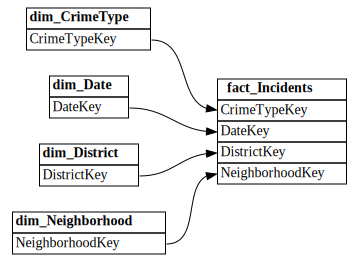

In [10]:
# Auto Date/Time disabled dataset

relationships = fabric.list_relationships(DATASET)

plot_relationship_metadata(relationships)

### Now Let's See What Happens With Auto Date/Time On

Same model structure. One setting flipped. 

This time we're pointing at a dataset where Auto Date/Time is enabled — and 
`plot_relationship_metadata()` will show you exactly what Power BI has been quietly 
building behind the scenes.

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 14, Finished, Available, Finished, False)

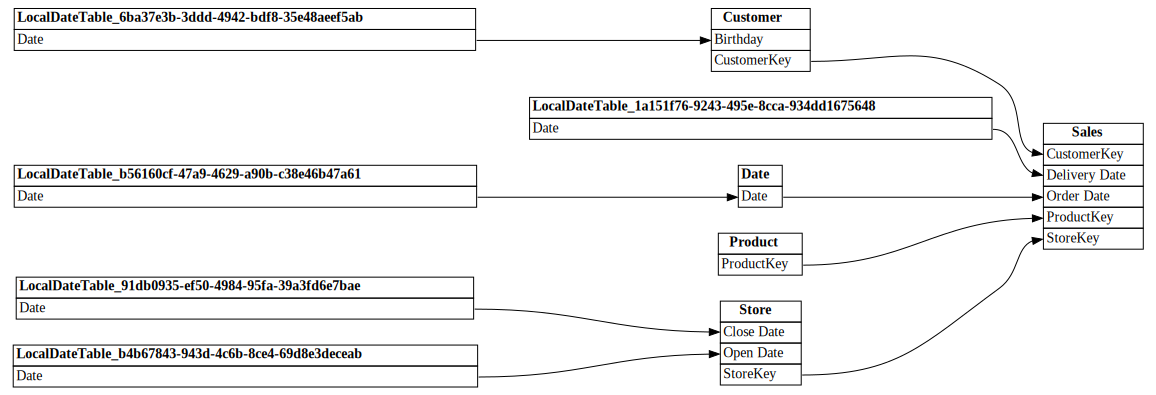

In [11]:
# Auto Date/Time enabled dataset
relationships = fabric.list_relationships(DATASET_AD)

plot_relationship_metadata(relationships)

### What Does the Data Actually Suggest?
So far we've mapped what the model *knows*. Now we ask what the data *tells us*.
`find_relationships()` works differently from anything we've used so far — it doesn't
read metadata. It reads the actual table data, comparing column values across tables
to find where keys overlap. Two parameters control the sensitivity:
- `coverage_threshold` — how much of the data must match to flag a candidate
- `name_similarity_threshold` — how similar column names need to be to be considered
What remains after stripping already-modeled pairs is what the data is actually trying to tell us.
> *"The clue was there the whole time. We just had to know what to ignore first."*

In [12]:
# What relationships does the DATA suggest?
# find_relationships needs actual table data — not column metadata
# fact_Incidents.ResolutionKey renamed to ResolutionsID in Power Query — breaks the relationship
# dim_Neighborhood.DistrictKey dropped in Power Query — no false positive
table_names = [
    "fact_Incidents",
    "dim_Date", "dim_CrimeType",
    "dim_District", "dim_Neighborhood", "dim_Resolution"
]

tables = {
    name: fabric.read_table(DATASET, name, workspace=WORKSPACE)
    for name in table_names
}

# coverage_threshold = what % of values must match to flag a relationship
suggested = find_relationships(
    tables,
    coverage_threshold=0.8,
    name_similarity_threshold=0.7
)

# Strip out pairs the model already knows about (in either direction)
modeled_pairs = set(
    zip(df_relationships["From Table"], df_relationships["To Table"])
) | set(
    zip(df_relationships["To Table"], df_relationships["From Table"])
)

unmodeled = suggested[
    ~suggested.apply(
        lambda r: (r["From Table"], r["To Table"]) in modeled_pairs, axis=1
    )
]

print(f"Unmodeled suggested relationships: {len(unmodeled)}")
display(unmodeled)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 15, Finished, Available, Finished, False)

Unmodeled suggested relationships: 1


SynapseWidget(Synapse.DataFrame, f4b2c01c-40ae-4945-8c39-4ade26897239)

---

## 📁 Case File #3 — "Running the Numbers"

> *The case breaks open.*

Two ways to get data out of the semantic model:
1. `read_table` — pull a full table into a pandas DataFrame
2. `evaluate_dax` — run a DAX query from Python and get the result back as a DataFrame

This is the **crossover moment** — your DAX knowledge, now programmable.

Find issues based on the data and not just the metadata

Setting: San Francisco. Monk's city. The data doesn't lie.

In [13]:
# Pull fact_Incidents into Python
df = fabric.read_table(DATASET, "fact_Incidents", workspace=WORKSPACE)

print(f"Rows loaded: {len(df):,}")
display(df.head(10))

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 16, Finished, Available, Finished, False)

Rows loaded: 500


SynapseWidget(Synapse.DataFrame, 09d946e1-42f0-4ea9-8dc0-5163db23ee3c)

### Clearance Rate by Crime Category

Not every case gets solved. Monk's would. But in the real world, clearance rates 
vary significantly by crime type.

This is pure pandas — `fabric.read_table()` collects the data to the driver node 
as a pandas DataFrame. For a model this size that's completely fine.

But worth knowing: you're in a PySpark notebook. If you were working with millions 
of rows, you'd want to stay distributed by using the pandas API on Spark instead:
```python
import pyspark.pandas as ps
```

Same familiar pandas syntax, but the computation stays in Spark across the cluster 
rather than being pulled to a single node. For small semantic models, pandas wins on 
simplicity. For large fact tables, Spark pandas wins on survival.

This is the kind of decision that doesn't matter today — until suddenly it does.

In [14]:
# Clearance rate by crime category — pure pandas
DATASET_Res = "SFCaseFiles_Res"

df_incidents  = fabric.read_table(DATASET_Res, "fact_Incidents", workspace=WORKSPACE)
df_resolution = fabric.read_table(DATASET_Res, "dim_Resolution", workspace=WORKSPACE)
df_crime      = fabric.read_table(DATASET_Res, "dim_CrimeType",  workspace=WORKSPACE)

clearance = (
    df_incidents
      .merge(df_resolution[["ResolutionKey", "Cleared"]], on="ResolutionKey", how="left")
      .merge(df_crime[["CrimeTypeKey", "Category"]], on="CrimeTypeKey", how="left")
      .groupby("Category", as_index=False)
      .agg(
          TotalIncidents=("CrimeTypeKey", "size"),
          ClearanceRate=("Cleared", "mean")
      )
      .sort_values("ClearanceRate", ascending=False)
)

clearance["ClearanceRate"] = clearance["ClearanceRate"].map("{:.1%}".format)
clearance = clearance.rename(columns={"Category": "Crime Category"})

display(clearance)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 17, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 437cfcc6-1dd3-4655-ae35-fefaff92445c)

### The Same Question — Asked in DAX

Pandas works. But your semantic model already has the business logic baked in — 
the relationships, the measures, the defined hierarchies.

`evaluate_dax()` lets you bring that DAX knowledge out of Power BI Desktop and into 
a notebook. Same clearance rate calculation, but now it runs against the semantic 
model, respects the modeled relationships, and returns a DataFrame you can keep 
working with in Python.

This is the bridge. Your DAX knowledge, now programmable.

In [15]:
# Same analysis — but using DAX via SLL
# Your DAX knowledge, now programmable

dax_query = """
EVALUATE
SUMMARIZECOLUMNS(
    dim_CrimeType[Category],
    "TotalIncidents", COUNTROWS(fact_Incidents),
    "ClearanceRate", DIVIDE(
        CALCULATE(
            COUNTROWS(fact_Incidents),
            dim_Resolution[Cleared] = TRUE()
        ),
        COUNTROWS(fact_Incidents)
    )
)
ORDER BY [TotalIncidents] DESC
"""

results = fabric.evaluate_dax(DATASET, dax_query, workspace=WORKSPACE)
results["[ClearanceRate]"] = results["[ClearanceRate]"].map("{:.1%}".format)

print("DAX result from Python:")
display(results)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 18, Finished, Available, Finished, False)

DAX result from Python:


SynapseWidget(Synapse.DataFrame, d03a83cd-3da9-4345-a11e-2f01bd205832)

### The Precinct Report — Breakdown by SFPD District

Monk never left San Francisco. Neither does this data.

Same `evaluate_dax()` pattern, different question. This time we're breaking incidents 
and clearance rates down by SFPD district — the same districts Monk would have 
navigated obsessively, noticing which precincts had the highest unsolved rates and 
exactly why that bothered him.

This is also a natural production pattern — swap the dimension, reuse the structure. 
One function call returns a district-level summary that could feed a report, a 
pipeline, or the next cell in this notebook.

In [16]:
# Breakdown by SFPD district
district_dax = """
EVALUATE
SUMMARIZECOLUMNS(
    dim_District[PoliceDistrict],
    "IncidentCount", COUNTROWS(fact_Incidents),
    "ClearanceRate", DIVIDE(
        CALCULATE(
            COUNTROWS(fact_Incidents),
            dim_Resolution[Cleared] = TRUE()
        ),
        COUNTROWS(fact_Incidents)
    )
)
ORDER BY [IncidentCount] DESC
"""

district_results = fabric.evaluate_dax(DATASET, district_dax, workspace=WORKSPACE)
district_results["[ClearanceRate]"] = district_results["[ClearanceRate]"].map("{:.1%}".format)

print("🗺️ Incidents by SFPD District:")
display(district_results)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 19, Finished, Available, Finished, False)

🗺️ Incidents by SFPD District:


SynapseWidget(Synapse.DataFrame, d361ae6e-9521-4701-b6b8-23a0d0bb2d62)

## 📁 Case File #4 — "Something Doesn't Add Up"
> *Every relationship has two sides. Not every key agrees.*

### Referential Integrity — The DAX Approach

Monk never ignores a loose end. In a semantic model, a loose end is an orphaned row — 
a fact table key that points to a dimension value that doesn't exist.

DAX gives us a way to surface these directly using `EXCEPT` — comparing the distinct 
keys in the fact table against what actually exists in the dimension.

> *"You'll thank me later."* — Adrian Monk

In [17]:
# Using DAX
# Using Except is us doing the detective work

dax = """
EVALUATE 
    EXCEPT (
        VALUES( 'Sales'[Order Date] ),
        VALUES('Date'[Date] )
    )
"""

fabric.evaluate_dax(
    dataset=DATASET_RI,
    dax_string= dax,
    workspace=WORKSPACE,
    verbose=0,
    num_rows=None
)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 20, Finished, Available, Finished, True)

,Sales[Order Date]
0,2017-12-29
1,2017-12-30
2,2017-12-31
3,2017-12-26
4,2017-12-27
...,...
193,2017-05-27
194,2017-05-29
195,2017-05-30
196,2017-05-31


### Referential Integrity — The `INFO.STORAGETABLES()` Approach

DAX's `EXCEPT` method finds the orphaned rows. But here's what Monk would appreciate 
more: the storage engine has *already been counting violations the whole time.*

`INFO.STORAGETABLES()` exposes internal storage engine metadata — including 
`RIVIOLATION_COUNT`, a built-in column that tracks RI violations at the table level. 
We just filter where that count is greater than zero.

No row-by-row comparison. The Vertipaq engine did the work. We're just reading its notes.

> *"I could be wrong. But I'm not."* — Adrian Monk

In [18]:
## Using info.storagetables()
## The engine filed a report for us

dax = """
EVALUATE
SELECTCOLUMNS(
	FILTER(
		INFO.STORAGETABLES(),
		[RIVIOLATION_COUNT] > 0 
	),
	"Table Name", [DIMENSION_NAME]
)
"""

fabric.evaluate_dax(
    dataset=DATASET_RI,
    dax_string= dax,
    workspace=WORKSPACE,
    verbose=0,
    num_rows=None
)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 21, Finished, Available, Finished, True)

,[Table Name]
0,Date


---
## 📁 Case File #5 — "The Evidence Isn't Ready Yet"

The witness statement exists. Monk knows it. But it's not in the file yet.

The pipeline gap:
```
Notebook writes Delta table
        ↓
OneLake  ← data lands HERE immediately
        ↓  [async background sync — can lag minutes]
SQL Analytics Endpoint  ← metadata appears HERE later
        ↓
Semantic Model / Power BI  ← and HERE last
```

The usual suspect: people assume a missing table means the semantic model needs a 
refresh. So they wait. Or they trigger a full refresh. Twenty minutes later, nothing 
changed — because the model was never the problem.

The actual suspect: the async metadata sync between OneLake and the SQL Analytics 
Endpoint. The data landed. The endpoint just hasn't caught up yet.

SLL gives you the programmatic call to force that sync — not a full semantic model 
refresh, just telling the endpoint to catch up to what OneLake already knows.

**Imagine time wasted if you keep refreshing the semantic model**

> *"You were looking at the wrong suspect the whole time."* — Adrian Monk


### Creating the Witness Table

Every case needs witnesses. We're creating `dim_Witness` — a small Delta table 
written directly to the Lakehouse from a notebook.

A few familiar faces in the witness list. Monk's address is accurate. 
Randy's credibility rating is also accurate.

This table exists purely to demonstrate the sync gap — we write it, then 
immediately check whether the SQL Analytics Endpoint knows it exists yet.


Spoiler: it won't.

In [19]:
# Monk always has a witness. Sometimes the witness IS Monk.

dim_witness = pd.DataFrame({
    "WitnessKey":    [1, 2, 3, 4, 5],
    "IncidentKey":   [42, 87, 213, 156, 301],
    "WitnessName":   [
        "Adrian Monk",
        "Natalie Teeger",
        "Captain Stottlemeyer",
        "Randy Disher",
        "Dr. Charles Kroger",
    ],
    "Address": [
        "1620 1/2 Broderick St, San Francisco, CA",
        "Unknown",
        "SFPD HQ, 1245 3rd St",
        "SFPD HQ, 1245 3rd St",
        "Clinic, Sutter St",
    ],
    "StatementDate": ["2023-04-01", "2023-04-01", "2023-04-02", "2023-04-02", "2023-04-03"],
    "Credible":      [True, True, True, False, True],
    "PhobiasNoted":  [312, 0, 0, 0, 0],
    "EndpointCheck": ["Original", "Original", "Original", "Original", "Original"]
})

spark_df = spark.createDataFrame(dim_witness)

spark_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("dim_Witness")

print("dim_Witness written to lakehouse as Delta table")
display(dim_witness)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 22, Finished, Available, Finished, False)

dim_Witness written to lakehouse as Delta table


SynapseWidget(Synapse.DataFrame, 8233a129-a6b6-4726-ae7c-5db44e2de2eb)

---

In [20]:
df = spark.sql("SELECT * FROM EvidenceLocker.dim_witness LIMIT 1000")
display(df)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 23, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, c2ed977e-07e8-4927-9872-1baef09686cf)

### Update table

In [2]:
spark.sql("""
UPDATE dim_Witness
SET EndpointCheck = 'UPDATED - Monk noticed the smudge'
WHERE WitnessKey = 1
""")

print("dim_Witness updated in lakehouse")

display(
    spark.sql("""
        SELECT WitnessKey, WitnessName, EndpointCheck
        FROM dim_Witness
        ORDER BY WitnessKey
    """)
)

StatementMeta(, ed3d21a1-746a-4a16-8c45-f78967d1c339, 5, Finished, Available, Finished, False)

dim_Witness updated in lakehouse


SynapseWidget(Synapse.DataFrame, 3481b811-c3f4-4ea5-befa-be405c64ba6d)

In [21]:
#SELECT WitnessKey, WitnessName, EndpointCheck
#FROM dim_Witness
#ORDER BY WitnessKey;

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 24, Finished, Available, Finished, False)

---

### The Endpoint Hasn't Caught Up Yet

The Delta table was just written. OneLake has it. But does the SQL Analytics Endpoint?

We check immediately — before any sync has had a chance to run. The expected result 
is that `dim_Witness` does not appear. That's not a failure. That's the whole point.

This is the gap that trips people up in production. The data is there. 
The endpoint just doesn't know it yet.

**Switch to the SQL Analytics Endpoint tab now and run the query.**

In [22]:
# The check happens outside this notebook
# Switch to the SQL Analytics Endpoint tab — run the INFORMATION_SCHEMA query
# Expected: dim_Witness does not appear yet
# Then check SSMS — SELECT TOP (1000) * FROM dim_Witness will return an error

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 25, Finished, Available, Finished, False)

### Calling in the Detective — Force the Endpoint to Sync

We know the data is there. Now we tell the SQL Analytics Endpoint to catch up.

`refresh_sql_endpoint_metadata()` is the right tool here — and it's worth being 
precise about what it does and what it doesn't do:

- Forces the SQL Analytics Endpoint to sync its metadata with OneLake
- Makes newly written Delta tables visible for T-SQL querying
- Does **NOT** trigger a full semantic model refresh
- Does **NOT** reload Power BI report visuals

This is a surgical fix. Not a sledgehammer.

Note the parameters — `item` takes the Lakehouse ID, not the name, and `type` must 
be specified as `"Lakehouse"`. Both `LAKEHOUSE_ID` and `WORKSPACE_ID` are defined 
in `00_Setup`.

In [3]:
# Force the SQL Analytics Endpoint to sync via SLL
# refresh_sql_endpoint_metadata targets the endpoint specifically —
# NOT a full semantic model refresh — this is the right tool for the job

# Confirm IDs are defined before attempting the sync
assert LAKEHOUSE_ID is not None, "LAKEHOUSE_ID not defined — re-run 00_Setup"
assert WORKSPACE_ID is not None, "WORKSPACE_ID not defined — re-run 00_Setup"
print(f"WORKSPACE_ID : {WORKSPACE_ID}")
print(f"LAKEHOUSE_ID : {LAKEHOUSE_ID}")

print("\n⏳ Triggering SQL Analytics Endpoint metadata refresh...")
labs.refresh_sql_endpoint_metadata(
    item=LAKEHOUSE_ID,
    type="Lakehouse",
    workspace=WORKSPACE_ID
)

print("Refresh complete — switch to the Analytics Endpoint tab and SSMS to verify")

StatementMeta(, ed3d21a1-746a-4a16-8c45-f78967d1c339, 6, Finished, Available, Finished, False)

WORKSPACE_ID : 21df5422-28b3-46aa-a1c5-ae2cd2a48578
LAKEHOUSE_ID : a5f11fba-90dd-4722-81a9-d9cc0ebc6fdc

⏳ Triggering SQL Analytics Endpoint metadata refresh...
🟢 The metadata of the SQL endpoint for the 'EvidenceLocker' lakehouse within the 'FabConSQLCon2026' workspace has been refreshed for all tables.
Refresh complete — switch to the Analytics Endpoint tab and SSMS to verify


### Back to the Evidence Room

Switch to the SQL Analytics Endpoint tab and SSMS.

Run the queries again. The witness is now in the file.

---

## 📁 Case File #6 — "The Witness Vanished"

The case was closed. The witness was in the file.

Then someone deleted the table.

In a traditional environment this is a bad day — a support ticket, a pipeline 
re-run, a conversation nobody wants to have. In Fabric, with SLL, it's a single 
function call.

`recover_lakehouse_object()` reaches into the Lakehouse and restores a deleted 
Delta table from its transaction log history. No pipeline re-run. No restore from 
backup. No bad conversation.

The witness is coming back.

### The Witness Is Back

Switch to the SQL Analytics Endpoint tab and SSMS.

Run the queries one more time.

> *"I solved the case. You're welcome."* — Adrian Monk

In [23]:
# Monk always has a witness. Sometimes the witness IS Monk.

dim_secondwitness = pd.DataFrame({
    "WitnessKey":    [1, 2, 3, 4, 5],
    "IncidentKey":   [42, 87, 213, 156, 301],
    "WitnessName":   [
        "Adrian Monk",
        "Natalie Teeger",
        "Captain Stottlemeyer",
        "Randy Disher",
        "Dr. Charles Kroger",
    ],
    "Address": [
        "1620 1/2 Broderick St, San Francisco, CA",
        "Unknown",
        "SFPD HQ, 1245 3rd St",
        "SFPD HQ, 1245 3rd St",
        "Clinic, Sutter St",
    ],
    "StatementDate": ["2023-04-01", "2023-04-01", "2023-04-02", "2023-04-02", "2023-04-03"],
    "Credible":      [True, True, True, False, True],
    "PhobiasNoted":  [312, 0, 0, 0, 0],
    "EndpointCheck": ["Original", "Original", "Original", "Original", "Original"]
})

spark_df = spark.createDataFrame(dim_witness)

spark_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("dim_secondWitness")

print("dim_secondWitness written to lakehouse as Delta table")
display(dim_secondwitness)

StatementMeta(, 6ce625d2-d3ae-476e-9c55-316e73e88124, 26, Finished, Available, Finished, True)

dim_secondWitness written to lakehouse as Delta table


SynapseWidget(Synapse.DataFrame, ba1e1a2d-ab49-48c8-9442-83177afc871c)

In [4]:
file_path = "Tables/dim_secondwitness"
lakehouse = LAKEHOUSE_ID
workspace = WORKSPACE_ID

labs.lakehouse.recover_lakehouse_object(
    file_path,
    lakehouse,
    workspace,
)


StatementMeta(, ed3d21a1-746a-4a16-8c45-f78967d1c339, 7, Finished, Available, Finished, False)

⌛ Attempting to recover the 'a5f11fba-90dd-4722-81a9-d9cc0ebc6fdc/Tables/dim_secondwitness' blob...
🟢 The 'a5f11fba-90dd-4722-81a9-d9cc0ebc6fdc/Tables/dim_secondwitness' blob recover attempt was successful.


---
## Session Wrap-Up

### What we covered:

| Case File | What you learned |
|---|---|
| #1 | SLL as a forensic model inventory tool |
| #2 | The relationship web — what the model knows and what the data suggests |
| #3 | DAX + Python together — your existing skills, now programmable |
| #4 | Referential integrity — the storage engine has been counting violations the whole time |
| #5 | The SQL Analytics Endpoint lag is real — and SLL lets you force the sync |
| #6 | Deleted lakehouse objects aren't gone — `recover_lakehouse_object()` brings them back |

### Resources:
- [Semantic Link Labs GitHub](https://github.com/microsoft/semantic-link-labs)
- [sempy docs — Microsoft Learn](https://learn.microsoft.com/en-us/fabric/data-science/semantic-link-overview)

> *"It's a gift... and a curse."* — Adrian Monk